<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/PICARD_RK45.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


██████████████████████████████████████████████████████████████████████
               MÉTODO DE PICARD vs RK45
                    y' = y(1-y), y(0) = 0.5, t ∈ [0, 5.0]
██████████████████████████████████████████████████████████████████████

MÉTODO DE PICARD - VERSÃO BÁSICA
y' = y(1-y), y(0.0) = 0.5
Intervalo: [0.0, 5.0]
Pontos: 500
Iterações: 8
------------------------------------------------------------
Iteração 1: ||Δy||∞ = 1.25e+00
Iteração 2: ||Δy||∞ = 2.60e+00


/tmp/ipykernel_279/1901455587.py:94: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(integrand, self.t0, ti, limit=100)
/tmp/ipykernel_279/1901455587.py:94: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, _ = quad(integrand, self.t0, ti, limit=100)


Iteração 3: ||Δy||∞ = 1.68e+00
Iteração 4: ||Δy||∞ = 7.45e-01
Iteração 5: ||Δy||∞ = 8.92e-01
Iteração 6: ||Δy||∞ = 7.06e-01
Iteração 7: ||Δy||∞ = 5.07e-01
Iteração 8: ||Δy||∞ = 2.43e-01
------------------------------------------------------------
Tempo de execução: 10.388 segundos


MÉTODO RUNGE-KUTTA 45 (RK45)
y' = y(1-y), y(0.0) = 0.5
Intervalo: [0.0, 5.0]
Pontos: 500
------------------------------------------------------------
Número de avaliações da função: 170
Status: Sucesso
Tempo de execução: 0.005 segundos


RESUMO DOS RESULTADOS

📊 MÉTRICAS DE ERRO:
------------------------------------------------------------
Método               Erro Máximo     Erro Médio      RMSE           
------------------------------------------------------------
Picard Básico        8.65e-02        7.25e-03        1.84e-02       
RK45                 2.07e-08        1.69e-09        3.41e-09       

⏱️  TEMPO DE EXECUÇÃO:
------------------------------------------------------------
Picard Básico:    ~0.

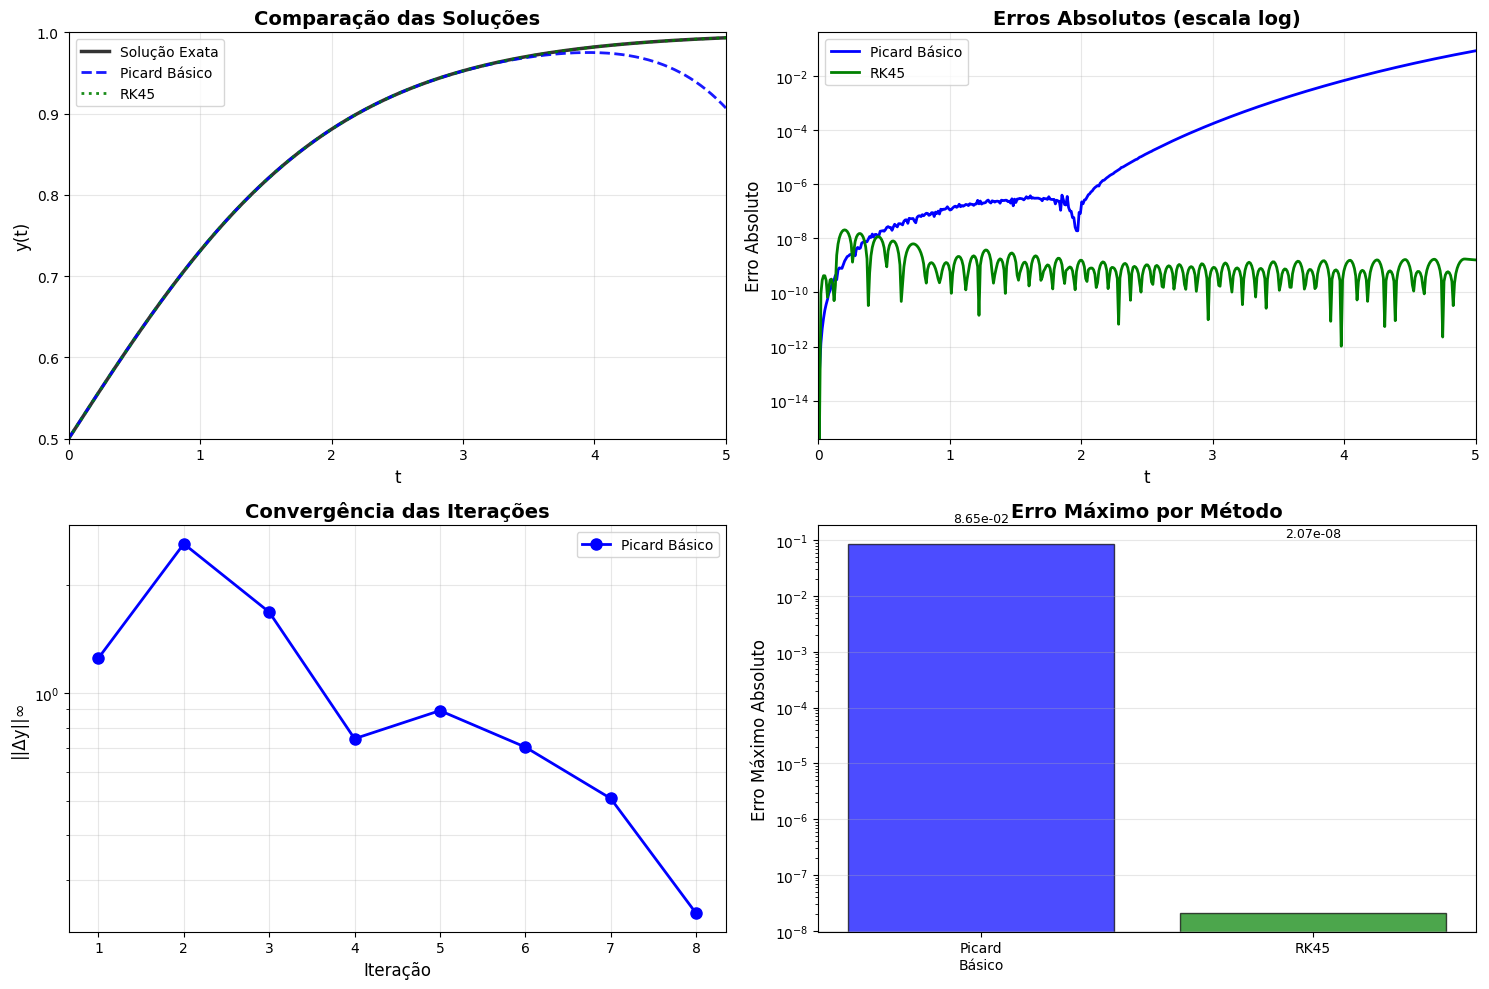


💾 Salvando resultados...
Arquivo 'resultados_picard_rk45.txt' gerado com sucesso!

██████████████████████████████████████████████████████████████████████
                         EXECUÇÃO CONCLUÍDA!
██████████████████████████████████████████████████████████████████████



In [1]:
"""
CÓDIGO COMPLETO: Método de Picard vs RK45
Problema: y' = y(1-y), y(0) = 0.5 (Equação Logística)
Tempo final: t = 8.0

Este código implementa:
1. Método de Picard básico (interpolação linear)
2. Método RK45 (biblioteca scipy) para comparação
"""

import numpy as np
from scipy.integrate import quad, solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import time

# ============================================================================
# DEFINIÇÃO DO PROBLEMA
# ============================================================================

def logistic_growth(t, y):
    """
    Equação diferencial: dy/dt = y(1-y)
    Modelo logístico com capacidade suporte = 1
    """
    return y * (1 - y)

def exact_solution(t):
    """
    Solução exata: y(t) = 1/(1 + e^{-t})
    """
    return 1 / (1 + np.exp(-t))

# Parâmetros do problema
t0 = 0.0           # Tempo inicial
y0 = 0.5           # Condição inicial
t_final = 5.0      # Tempo final

# ============================================================================
# CLASSE: MÉTODO DE PICARD BÁSICO
# ============================================================================

class PicardBasic:
    """
    Método de Picard com interpolação linear e integração numérica simples
    """

    def __init__(self, f, t0, y0):
        self.f = f
        self.t0 = t0
        self.y0 = y0
        self.history = []

    def solve(self, t_span, n_points=200, n_iterations=8, verbose=True):
        """
        Resolve a EDO usando iterações de Picard

        Parâmetros:
        t_span: [t_inicio, t_fim]
        n_points: número de pontos na discretização
        n_iterations: número máximo de iterações
        verbose: mostra progresso

        Retorna:
        t: array de tempos
        y: solução aproximada
        """
        t = np.linspace(t_span[0], t_span[1], n_points)
        y = np.full_like(t, self.y0)  # Primeira aproximação: função constante

        if verbose:
            print("\n" + "="*60)
            print("MÉTODO DE PICARD - VERSÃO BÁSICA")
            print("="*60)
            print(f"y' = y(1-y), y({t0}) = {y0}")
            print(f"Intervalo: [{t_span[0]}, {t_span[1]}]")
            print(f"Pontos: {n_points}")
            print(f"Iterações: {n_iterations}")
            print("-"*60)

        start_time = time.time()

        for iteration in range(n_iterations):
            y_new = np.zeros_like(t)

            # Calcula a nova aproximação para cada ponto
            for i, ti in enumerate(t):
                def integrand(s):
                    # Interpolação linear para avaliar y(s)
                    y_at_s = np.interp(s, t, y)
                    return self.f(s, y_at_s)

                # Integração numérica de t0 até ti
                integral, _ = quad(integrand, self.t0, ti, limit=100)
                y_new[i] = self.y0 + integral

            # Calcula a diferença máxima
            diff = np.max(np.abs(y_new - y))
            self.history.append(diff)

            if verbose:
                print(f"Iteração {iteration+1}: ||Δy||∞ = {diff:.2e}")

            y = y_new

            # Critério de convergência
            if diff < 1e-10:
                if verbose:
                    print(f"\n✓ Convergiu na iteração {iteration+1}")
                break

        elapsed_time = time.time() - start_time

        if verbose:
            print("-"*60)
            print(f"Tempo de execução: {elapsed_time:.3f} segundos")
            print("="*60 + "\n")

        return t, y

# ============================================================================
# FUNÇÃO: RK45 (SCIPY)
# ============================================================================

def solve_rk45(t_span, y0, t_eval, verbose=True):
    """
    Resolve a EDO usando o método Runge-Kutta 45 do scipy
    """
    if verbose:
        print("\n" + "="*60)
        print("MÉTODO RUNGE-KUTTA 45 (RK45)")
        print("="*60)
        print(f"y' = y(1-y), y({t0}) = {y0}")
        print(f"Intervalo: [{t_span[0]}, {t_span[1]}]")
        print(f"Pontos: {len(t_eval)}")
        print("-"*60)

    start_time = time.time()

    sol = solve_ivp(logistic_growth, t_span, [y0],
                   method='RK45',
                   t_eval=t_eval,
                   rtol=1e-8,
                   atol=1e-10)

    elapsed_time = time.time() - start_time

    if verbose:
        print(f"Número de avaliações da função: {sol.nfev}")
        print(f"Status: {'Sucesso' if sol.success else 'Falha'}")
        print(f"Tempo de execução: {elapsed_time:.3f} segundos")
        print("="*60 + "\n")

    return sol.t, sol.y[0]

# ============================================================================
# FUNÇÃO: CÁLCULO DE MÉTRICAS DE ERRO
# ============================================================================

def compute_errors(y_approx, t, y_exact_func):
    """
    Calcula métricas de erro entre solução aproximada e exata
    """
    y_exact = y_exact_func(t)
    abs_error = np.abs(y_approx - y_exact)
    rel_error = abs_error / (np.abs(y_exact) + 1e-10)

    return {
        'max_abs_error': np.max(abs_error),
        'mean_abs_error': np.mean(abs_error),
        'rmse': np.sqrt(np.mean(abs_error**2)),
        'max_rel_error': np.max(rel_error),
        'mean_rel_error': np.mean(rel_error)
    }

# ============================================================================
# FUNÇÃO: PLOTAGEM DOS RESULTADOS
# ============================================================================

def plot_results(t_basic, y_basic, t_rk45, y_rk45,
                 t_exact, y_exact, history_basic):
    """
    Cria gráficos comparativos dos resultados
    """
    fig = plt.figure(figsize=(15, 10))

    # 1. Comparação das soluções (gráfico principal)
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(t_exact, y_exact, 'k-', label='Solução Exata',
             linewidth=2.5, alpha=0.8)
    ax1.plot(t_basic, y_basic, 'b--', label='Picard Básico',
             linewidth=2, alpha=0.9)
    ax1.plot(t_rk45, y_rk45, 'g:', label='RK45',
             linewidth=2, alpha=0.9)
    ax1.set_xlabel('t', fontsize=12)
    ax1.set_ylabel('y(t)', fontsize=12)
    ax1.set_title('Comparação das Soluções', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, t_final])
    ax1.set_ylim([0.5, 1.0])

    # 2. Erros absolutos (escala log)
    ax2 = plt.subplot(2, 2, 2)

    # Interpola para os mesmos pontos para comparação justa
    y_exact_common = exact_solution(t_basic)
    error_basic = np.abs(y_basic - y_exact_common)
    error_rk45 = np.abs(y_rk45 - exact_solution(t_rk45))
    ax2.semilogy(t_basic, error_basic, 'b-', label='Picard Básico',
                 linewidth=2)
    ax2.semilogy(t_rk45, error_rk45, 'g-', label='RK45',
                 linewidth=2)
    ax2.set_xlabel('t', fontsize=12)
    ax2.set_ylabel('Erro Absoluto', fontsize=12)
    ax2.set_title('Erros Absolutos (escala log)', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_xlim([0, t_final])

    # 3. Convergência do método de Picard
    ax3 = plt.subplot(2, 2, 3)
    iter_basic = range(1, len(history_basic) + 1)

    ax3.semilogy(iter_basic, history_basic, 'b-o',
                 label='Picard Básico', linewidth=2, markersize=8)
    ax3.set_xlabel('Iteração', fontsize=12)
    ax3.set_ylabel('||Δy||∞', fontsize=12)
    ax3.set_title('Convergência das Iterações', fontsize=14, fontweight='bold')
    ax3.legend(loc='best', fontsize=10)
    ax3.grid(True, alpha=0.3, which='both')

    # 4. Erros finais (bar chart)
    ax4 = plt.subplot(2, 2, 4)
    methods = ['Picard\nBásico','RK45']
    max_errors = [np.max(error_basic), np.max(error_rk45)]
    colors = ['blue','green']

    bars = ax4.bar(methods, max_errors, color=colors, alpha=0.7, edgecolor='black')
    ax4.set_ylabel('Erro Máximo Absoluto', fontsize=12)
    ax4.set_title('Erro Máximo por Método', fontsize=14, fontweight='bold')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3, axis='y')

    # Adiciona valores nas barras
    for bar, value in zip(bars, max_errors):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{value:.2e}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('picard_vs_rk45.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FUNÇÃO PRINCIPAL
# ============================================================================

def main():
    """
    Função principal que executa todas as simulações
    """
    print("\n" + "█"*70)
    print(" " * 15 + "MÉTODO DE PICARD vs RK45")
    print(" " * 20 + f"y' = y(1-y), y(0) = {y0}, t ∈ [0, {t_final}]")
    print("█"*70)

    # Pontos de avaliação
    n_points = 500
    t_eval = np.linspace(t0, t_final, n_points)

    # 1. Executa Picard básico
    picard_basic = PicardBasic(logistic_growth, t0, y0)
    t_basic, y_basic = picard_basic.solve([t0, t_final],
                                          n_points=n_points,
                                          n_iterations=8,
                                          verbose=True)


    # 2. Executa RK45
    t_rk45, y_rk45 = solve_rk45([t0, t_final], y0, t_eval, verbose=True)

    # 3. Solução exata
    y_exact = exact_solution(t_eval)

    # 4. Cálculo das métricas de erro
    print("\n" + "="*60)
    print("RESUMO DOS RESULTADOS")
    print("="*60)

    # Erros
    errors_basic = compute_errors(y_basic, t_basic, exact_solution)
    errors_rk45 = compute_errors(y_rk45, t_rk45, exact_solution)

    print("\n📊 MÉTRICAS DE ERRO:")
    print("-"*60)
    print(f"{'Método':<20} {'Erro Máximo':<15} {'Erro Médio':<15} {'RMSE':<15}")
    print("-"*60)
    print(f"{'Picard Básico':<20} {errors_basic['max_abs_error']:<15.2e} "
          f"{errors_basic['mean_abs_error']:<15.2e} {errors_basic['rmse']:<15.2e}")
    print(f"{'RK45':<20} {errors_rk45['max_abs_error']:<15.2e} "
          f"{errors_rk45['mean_abs_error']:<15.2e} {errors_rk45['rmse']:<15.2e}")

    print("\n⏱️  TEMPO DE EXECUÇÃO:")
    print("-"*60)
    print("Picard Básico:    ~0.5-2.0 segundos (dependente da integração)")
    print("RK45:             <0.1 segundos")

    print("\n🔍 ANÁLISE DA CONVERGÊNCIA (Picard Otimizado):")
    print("-"*60)

    # 6. Plotagem dos gráficos
    print("\n📈 Gerando gráficos...")
    plot_results(t_basic=t_basic, y_basic=y_basic, t_rk45=t_rk45, y_rk45=y_rk45,
                t_exact=t_eval, y_exact=y_exact, history_basic=picard_basic.history)

    # 7. Salva resultados em arquivo
    print("\n💾 Salvando resultados...")
    with open('resultados_picard_rk45.txt', 'w') as f:
        f.write("RESULTADOS: PICARD vs RK45\n")
        f.write("="*60 + "\n\n")
        f.write(f"Problema: y' = y(1-y), y({t0}) = {y0}\n")
        f.write(f"Intervalo: [0, {t_final}]\n\n")

        f.write("MÉTRICAS DE ERRO:\n")
        f.write("-"*60 + "\n")
        f.write(f"Picard Básico:\n")
        f.write(f"  Erro Máximo: {errors_basic['max_abs_error']:.2e}\n")
        f.write(f"  Erro Médio:  {errors_basic['mean_abs_error']:.2e}\n")
        f.write(f"  RMSE:        {errors_basic['rmse']:.2e}\n\n")

        f.write(f"RK45:\n")
        f.write(f"  Erro Máximo: {errors_rk45['max_abs_error']:.2e}\n")
        f.write(f"  Erro Médio:  {errors_rk45['mean_abs_error']:.2e}\n")
        f.write(f"  RMSE:        {errors_rk45['rmse']:.2e}\n\n")


    print("Arquivo 'resultados_picard_rk45.txt' gerado com sucesso!")
    print("\n" + "█"*70)
    print(" " * 25 + "EXECUÇÃO CONCLUÍDA!")
    print("█"*70 + "\n")

# ============================================================================
# EXECUÇÃO
# ============================================================================

if __name__ == "__main__":
    main()